In [1]:
include("../src/main.jl");

In [2]:
dump_filepath = "../src/models/iharm3dDumps/dump_001.h5";

In [3]:
params = read_header(dump_filepath);

In [4]:
bhspin = params["bhspin"]

#METRIC = params["METRIC"]
#N1 = params["N1"]
#trat_large = params["trat_large"]
#trat_small = params["trat_small"]
#beta_crit = params["beta_crit"]
#game = params["game"]
#gamp = params["gamp"]
#gam = params["gam"]
#Ne_factor = params["Ne_factor"]
#rmin_geo = params["rmin_geo"]
#rmax_geo = params["rmax_geo"]
#th_beg = params["th_beg"]
#sigma_cut = params["sigma_cut"]
#sigma_cut_high = params["sigma_cut_high"]
#startx = params["startx"]
#stopx = params["stopx"]
#dx = params["dx"]
#hslope = params["hslope"]
#N2 = params["N2"]
#N3 = params["N3"]

0.9475

In [7]:
#TODO: put this in reading file
N1 = 128
N2 = 64
N3 = 32

trat_large = 20. #TODO: prob have to be read from file
trat_small = 1. #TODO: prob have to be read from file
beta_crit = 1.0 #TODO: prob have to be read from file
game = (4. /3.)  # Ion adiabatic index  TODO: prob have to be read from file
gamp = (5. /3.)  # Electron adiabatic index TODO: prob have to be read from file
gam = (13. /9.)  # Total adiabatic index TODO: prob have to be read from file
Ne_factor = 1.0  # Scaling factor for electron number density TODO: prob have to be read from file
rmin_geo = 1.001875757988324 #TODO: Has to be read from file as Rin and compared to the value chosen
rmax_geo = 100. #TODO: Has to be read from file as Rin and compared to the value chosen
th_beg = 1.74e-2 #TODO: Idk where this comes from, check ipole source code
sigma_cut = 1.0 #TODO: maybe put it somewhere else?
sigma_cut_high = -1.0
startx::MVec4 = [0, 1.874000951149813e-03, 0, 0]#TODO: prob have to be read from file
stopx::MVec4 = [1, 6.907755278982138e+00, 1, 2 * π]#TODO: prob have to be read from file
dx::MVec4 = [0, 5.395219748461709e-02, 1.562500000000000e-02, 1.963495408493621e-01] #TODO: prob have to be read from file
#bhspin = 0.9375 #TODO: prob have to be read from file
hslope = 0.3 #TODO: prob have to be read from file


0.3

In [5]:
#Analytic parameters

#Setting up the parameters
#Observer distance in Rg
ro = 1000.0
#Observer inclination in degrees
th = 17.0

#Observer azimuth in degrees
phi = 0.0

# Number of pixels in the x and y direction. The number of geodesics calculated will be res^2
res = 40
pixels_x = 40
pixels_y = 40
# Distance to the source in parsecs
SourceD = 16.9e6 * PC
Rout = 1000.0
Rstop = 100.0
Rh = 1 + sqrt(1. - bhspin * bhspin);

#Check if these are correct
cstartx = [0.0, log(Rh), 0.0, 0.0]#TODO: prob have to be read from file
cstopx = [0.0, log(1000.0), 1.0, 2.0 * π]#TODO: prob have to be read from file

# Frequency observed by the camera in Hz
freq = 230e9;

# Size of the screen in Rg in both directions
DXsize = SourceD/L_unit/MUAS_PER_RAD * 160
DYsize = SourceD/L_unit/MUAS_PER_RAD * 160
# Observer fov in radians (this can be understood as size of the plane camera sees over the distance ro)
# This should be atan, but for small angles it is approximately equal to the angle itself
fovx = DXsize/ro
fovy = DYsize/ro
xoff = 0.0
yoff = 0.0


0.0

In [6]:
#TODO: Ipole and Jipole are not matching geodesics perfectly to 15 decimals (it could be an effect of get_connection)
include("../src/main.jl");
# Find camera in native coordinates
Xcamera = MVec4(camera_position(ro, th, phi, bhspin, Rout))

# Scales the intensity of each pixel by the real size of each pixel
scale_factor = CalculateScaleFactor(DXsize, DYsize, pixels_x, pixels_y, SourceD, L_unit)
println("scale_factor = $scale_factor")
maxnstep = 15000
# Generate geodesics
println("Utilizing $(Threads.nthreads()) threads for geodesic calculation.")
freq_unitless = freq * HPL/(ME * CL * CL)  # Convert frequency to unitless
Image = zeros(Float64, pixels_x, pixels_y)
for i in 0:(pixels_x - 1)
    println("Processing row $i out of $(pixels_x)")

    Threads.@threads for j in 0:(pixels_y - 1)
        traj = Vector{OfTraj}()
        sizehint!(traj, maxnstep)

        nstep = get_pixel(traj, i, j, Xcamera, maxnstep, fovx, fovy, freq_unitless, pixels_x, pixels_y, bhspin, Rh, Rout, Rstop, xoff, yoff)

        resize!(traj, length(traj))
        integrate_emission!(traj, length(traj), Image, i + 1, j + 1, freq, bhspin, simulation_data)
    end
end
Image *= freq^3;

scale_factor = 37.6070182109265
Utilizing 5 threads for geodesic calculation.
Processing row 0 out of 40
sth 1.0, cth 6.123233995736766e-17, r 999.9999999999998, a 0.0, rho2 999999.9999999995, tfac 1.0, rfac 999.9999999999998, hfac 0.0, pfac 1.0
X = [0.0, 6.907755278982137, 4.6663180925160944e-302, 0.0]
th = 1.5707963267948966
sth 1.0, cth 6.123233995736766e-17, r 999.9999999999998, a 0.0, rho2 999999.9999999995, tfac 1.0, rfac 999.9999999999998, hfac 0.0, pfac 1.0
Matrix: gcov
X = [0.0, 6.907755278982137, 4.6663180925160944e-302, 0.0]
sth 1.0, cth 6.123233995736766e-17, r 999.9999999999998, a 0.0, rho2 999999.9999999995, tfac 1.0, rfac 999.9999999999998, hfac 0.0, pfac 1.0
sth 1.0, cth 6.123233995736766e-17, r 999.9999999999998, a 0.0, rho2 999999.9999999995, tfac 1.0, rfac 999.9999999999998, hfac 0.0, pfac 1.0
sth 1.0, cth 6.123233995736766e-17, r 999.9999999999998, a 0.0, rho2 999999.9999999995, tfac 1.0, rfac 999.9999999999998, hfac 0.0, pfac 1.0
th = 1.5707963267948966
Matrix: gco

┌ Error: Singular gcov encountered in gcov_func
└ @ Main ~/Jipole_JAN_26 (copy 2)/src/metrics.jl:123
┌ Error: Singular gcov encountered in gcov_func
└ @ Main ~/Jipole_JAN_26 (copy 2)/src/metrics.jl:123
┌ Error: Singular gcov encountered in gcov_func
└ @ Main ~/Jipole_JAN_26 (copy 2)/src/metrics.jl:123
┌ Error: Singular gcov encountered in gcov_func
└ @ Main ~/Jipole_JAN_26 (copy 2)/src/metrics.jl:123
┌ Error: Singular gcov encountered in gcov_func
└ @ Main ~/Jipole_JAN_26 (copy 2)/src/metrics.jl:123


-9.980000000000000e-01 -9.980000000000000e-01 -9.980000000000000e-01 -9.980000000000000e-01 -9.980000000000000e-01 2.000000000000000e+00 2.000000000000000e+00 2.000000000000000e+00 2.000000000000000e+00 0.000000000000000e+00 0.000000000000000e+00 0.000000000000000e+00 0.000000000000000e+00 2.000000000000000e+00 -0.000000000000000e+00 -0.000000000000000e+00 -0.000000000000000e+00 -0.000000000000000e+00 0.000000000000000e+00 -0.000000000000000e+00 




2.000000000000000e+00 2.000000000000000e+00 2.000000000000000e+00 2.000000000000000e+00 2.000000000000000e+00 1.002000000000000e+06 1.002000000000000e+06 1.002000000000000e+06 1.002000000000000e+06 1.002000000000000e+06 -0.000000000000000e+00 -0.000000000000000e+00 -0.000000000000000e+00 -0.000000000000000e+00 -0.000000000000000e+00 -0.000000000000000e+00 -0.000000000000000e+00 -0.000000000000000e+00 -0.000000000000000e+00 -0.000000000000000e+00 




0.000000000000000e+00 0.000000000000000e+00 0.000000000000000e+00 0.000000000000000e+00 0.

LoadError: TaskFailedException

[91m    nested task error: [39mSingular gcov encountered, cannot compute gcov_func.
    Stacktrace:
      [1] [0m[1merror[22m[0m[1m([22m[90ms[39m::[0mString[0m[1m)[22m
    [90m    @[39m [90mBase[39m [90m./[39m[90m[4merror.jl:44[24m[39m
      [2] [0m[1mgcov_func[22m[0m[1m([22m[90mX[39m::[0mMVector[90m{4, Float64}[39m, [90mbhspin[39m::[0mFloat64, [90mR0[39m::[0mFloat64[0m[1m)[22m
    [90m    @[39m [35mMain[39m [90m~/Jipole_JAN_26 (copy 2)/src/[39m[90m[4mmetrics.jl:128[24m[39m
      [3] [0m[1mgcov_func[22m
    [90m    @[39m [90m~/Jipole_JAN_26 (copy 2)/src/[39m[90m[4mmetrics.jl:69[24m[39m[90m [inlined][39m
      [4] [0m[1mmake_camera_tetrad[22m[0m[1m([22m[90mX[39m::[0mMVector[90m{4, Float64}[39m, [90mbhspin[39m::[0mFloat64[0m[1m)[22m
    [90m    @[39m [35mMain[39m [90m~/Jipole_JAN_26 (copy 2)/src/[39m[90m[4mtetrads.jl:24[24m[39m
      [5] [0m[1minit_XK![22m[0m

In [ ]:
OutputStokesParameters(Image, freq, scale_factor, res, SourceD)

In [15]:
using DelimitedFiles

writedlm("./Image.txt", Image)


In [16]:
using DelimitedFiles

Image_loaded = readdlm("./Image.txt")


40×40 Matrix{Float64}:
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  …  0.0  0.0  0.0          0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0          0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0          0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0          0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0          0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  …  0.0  0.0  0.000405409  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0          0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0          0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0          0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0          0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  …  0.0  0.0  0.0          0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0          0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0        

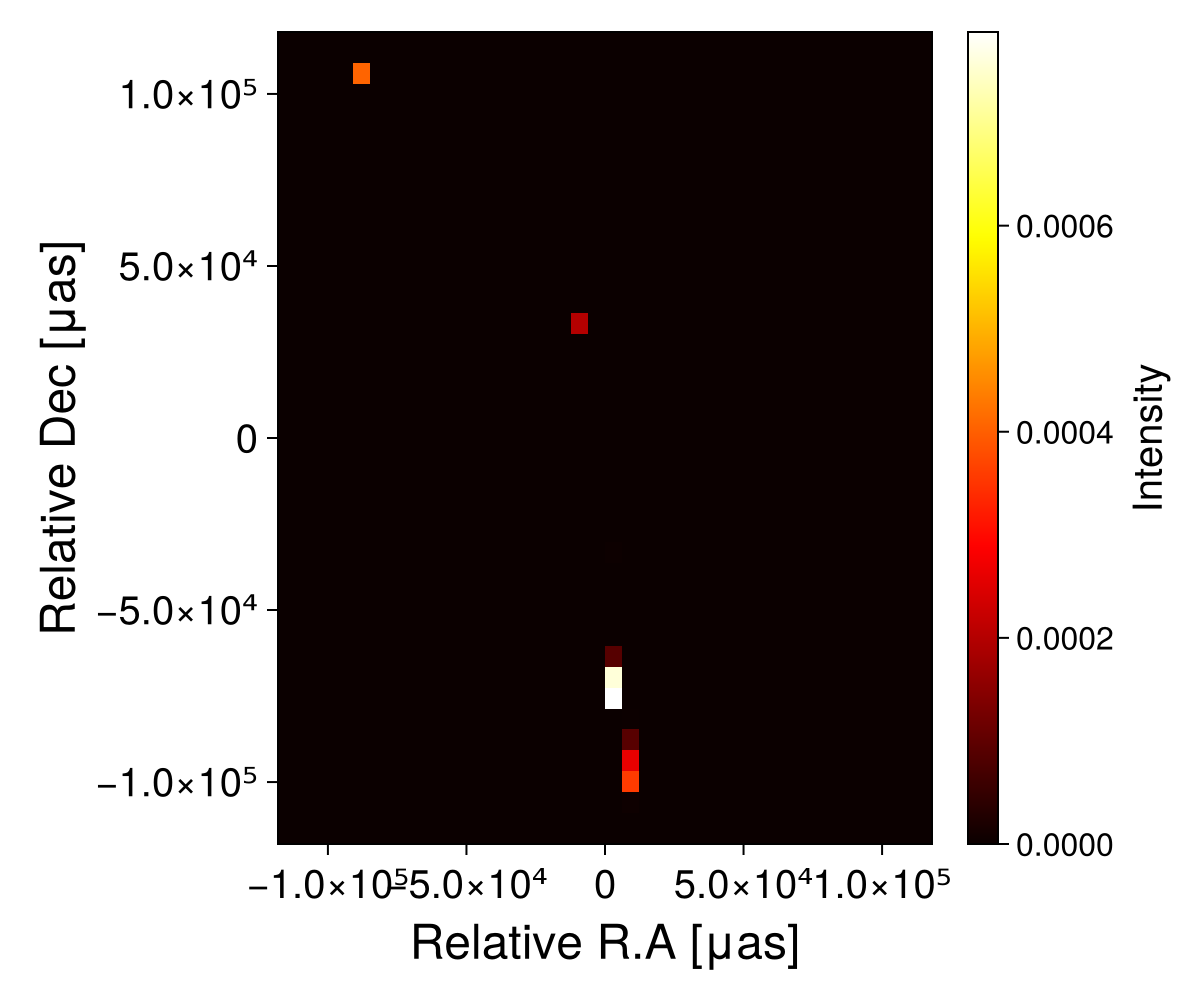

In [17]:
using CairoMakie
using Printf

d_kpc = 7.78
d_cm = d_kpc * 3.086e21           # distance in cm
fov_rg = 30                       # field of view in gravitational radii
half_fov_rg = fov_rg / 2

# Angular resolution
theta_rad = (half_fov_rg * L_unit) / d_cm   # half FOV in radians
theta_μas = theta_rad * MUAS_PER_RAD        # convert to μas
xlims = (-theta_μas, theta_μas)
ylims = (-theta_μas, theta_μas)

# Generate mock image (or load your 128x128 array here)
img = Image

# Axes
Ny, Nx = size(img)
x = range(xlims[1], xlims[2], length=Nx)
y = range(ylims[1], ylims[2], length=Ny)

# Plot
fig = Figure(size = (600, 500))
ax = Axis(fig[1, 1],
    xlabel = "Relative R.A [μas]",
    ylabel = "Relative Dec [μas]",
    xlabelsize=24,
    ylabelsize=24,
    xticklabelsize=20,
    yticklabelsize=20,
    limits = (xlims, ylims)
)

# Heatmap with color range
crange = extrema(img)
hm = heatmap!(ax, x, y, img; colormap=:hot, colorrange=crange)

# Colorbar
Colorbar(fig[1, 2], hm;
    label = "Intensity",
    labelsize = 20,
    ticklabelsize = 16,
    width = 15
)

fig

In [10]:
Image[13,21]*freq^3

1.1263398156531173e30

In [6]:
# From Ipole

In [11]:
using HDF5

function load_ipole_unpol(fname)
    hfp = h5open(fname, "r") do file
        # Read values
        dx = read(file["header/camera/dx"])
        dsource = read(file["header/dsource"])
        lunit = read(file["header/units/L_unit"])
        scale = read(file["header/scale"])

        fov_muas = dx / dsource * lunit * 2.06265e11

        # evpa_0 might not exist
        evpa_0 = haskey(file["header"], "evpa_0") ? read(file["header/evpa_0"]) : "W"

        # Load and transpose unpol
        unpol = read(file["unpol"])
        unpol_t = permutedims(unpol, (2,1))

        return unpol_t, fov_muas, scale, evpa_0
    end

    return hfp
end

load_ipole_unpol (generic function with 1 method)

In [12]:
Image1, _, _, _= load_ipole_unpol("../../ipole/image.h5")

([8.450927640761111e-5 8.491049973642485e-5 … 0.0022769676175104178 0.0022407711898049794; 8.489567446730451e-5 8.529679328840891e-5 … 0.0021673944913924103 0.002150253338457277; … ; 0.00012050894223055957 0.00012054514495224775 … 0.0006470523024849035 0.0006269223992664498; 0.0001245554052515976 0.00012265141199230547 … 0.0005964698297159676 0.0005773315918254562], 160.0, 0.5876096595457265, "N")

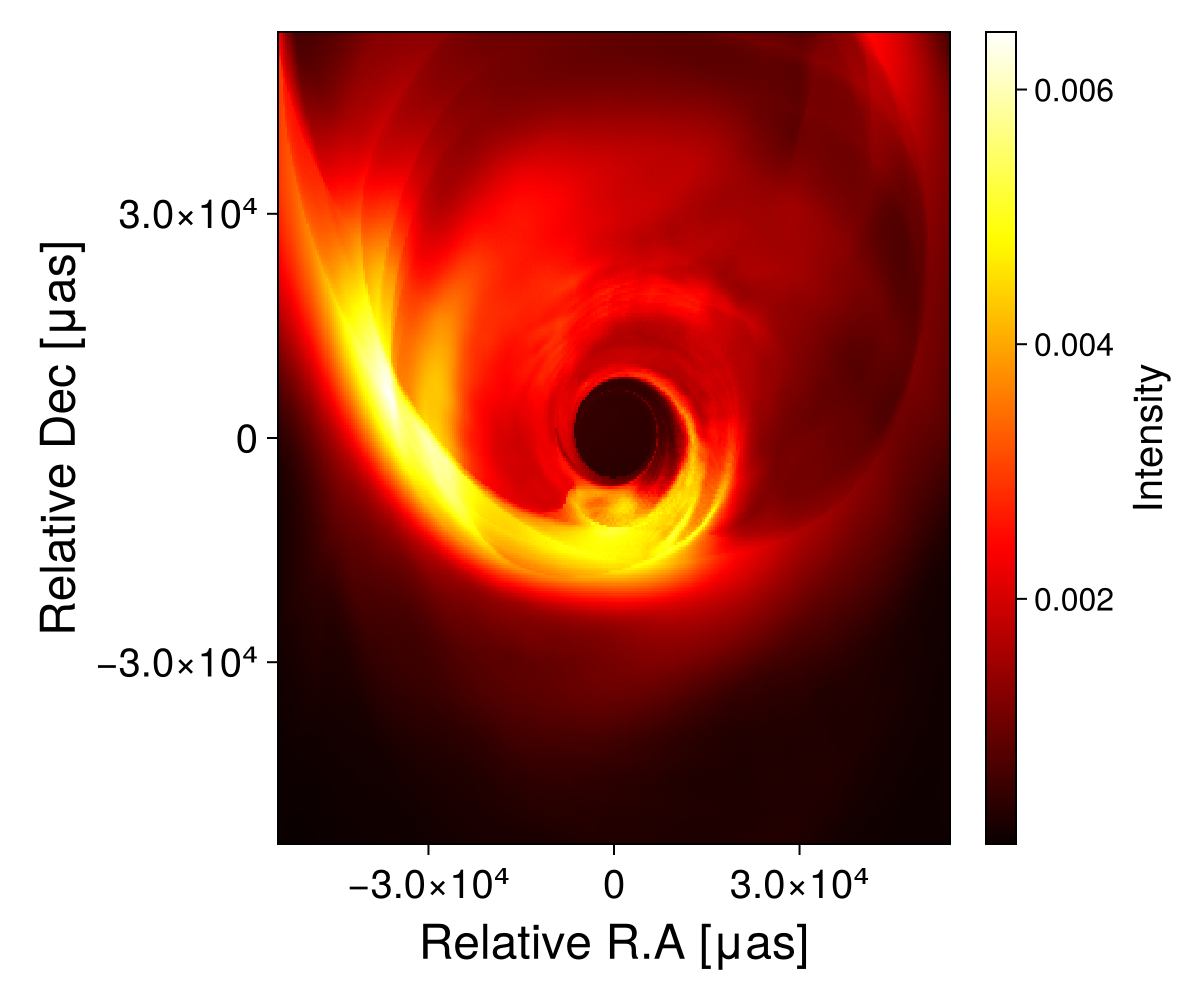

In [13]:
using CairoMakie
using Printf

d_kpc = 16.9
d_cm = d_kpc * 3.086e21           # distance in cm
fov_rg = 30                       # field of view in gravitational radii
half_fov_rg = fov_rg / 2

# Angular resolution
theta_rad = (half_fov_rg * L_unit) / d_cm   # half FOV in radians
theta_μas = theta_rad * MUAS_PER_RAD        # convert to μas
xlims = (-theta_μas, theta_μas)
ylims = (-theta_μas, theta_μas)

# Generate mock image (or load your 128x128 array here)
img = Image1

# Axes
Ny, Nx = size(img)
x = range(xlims[1], xlims[2], length=Nx)
y = range(ylims[1], ylims[2], length=Ny)

# Plot
fig = Figure(size = (600, 500))
ax = Axis(fig[1, 1],
    xlabel = "Relative R.A [μas]",
    ylabel = "Relative Dec [μas]",
    xlabelsize=24,
    ylabelsize=24,
    xticklabelsize=20,
    yticklabelsize=20,
    limits = (xlims, ylims)
)

# Heatmap with color range
crange = extrema(img)
hm = heatmap!(ax, x, y, img; colormap=:hot, colorrange=crange)

# Colorbar
Colorbar(fig[1, 2], hm;
    label = "Intensity",
    labelsize = 20,
    ticklabelsize = 16,
    width = 15
)

fig


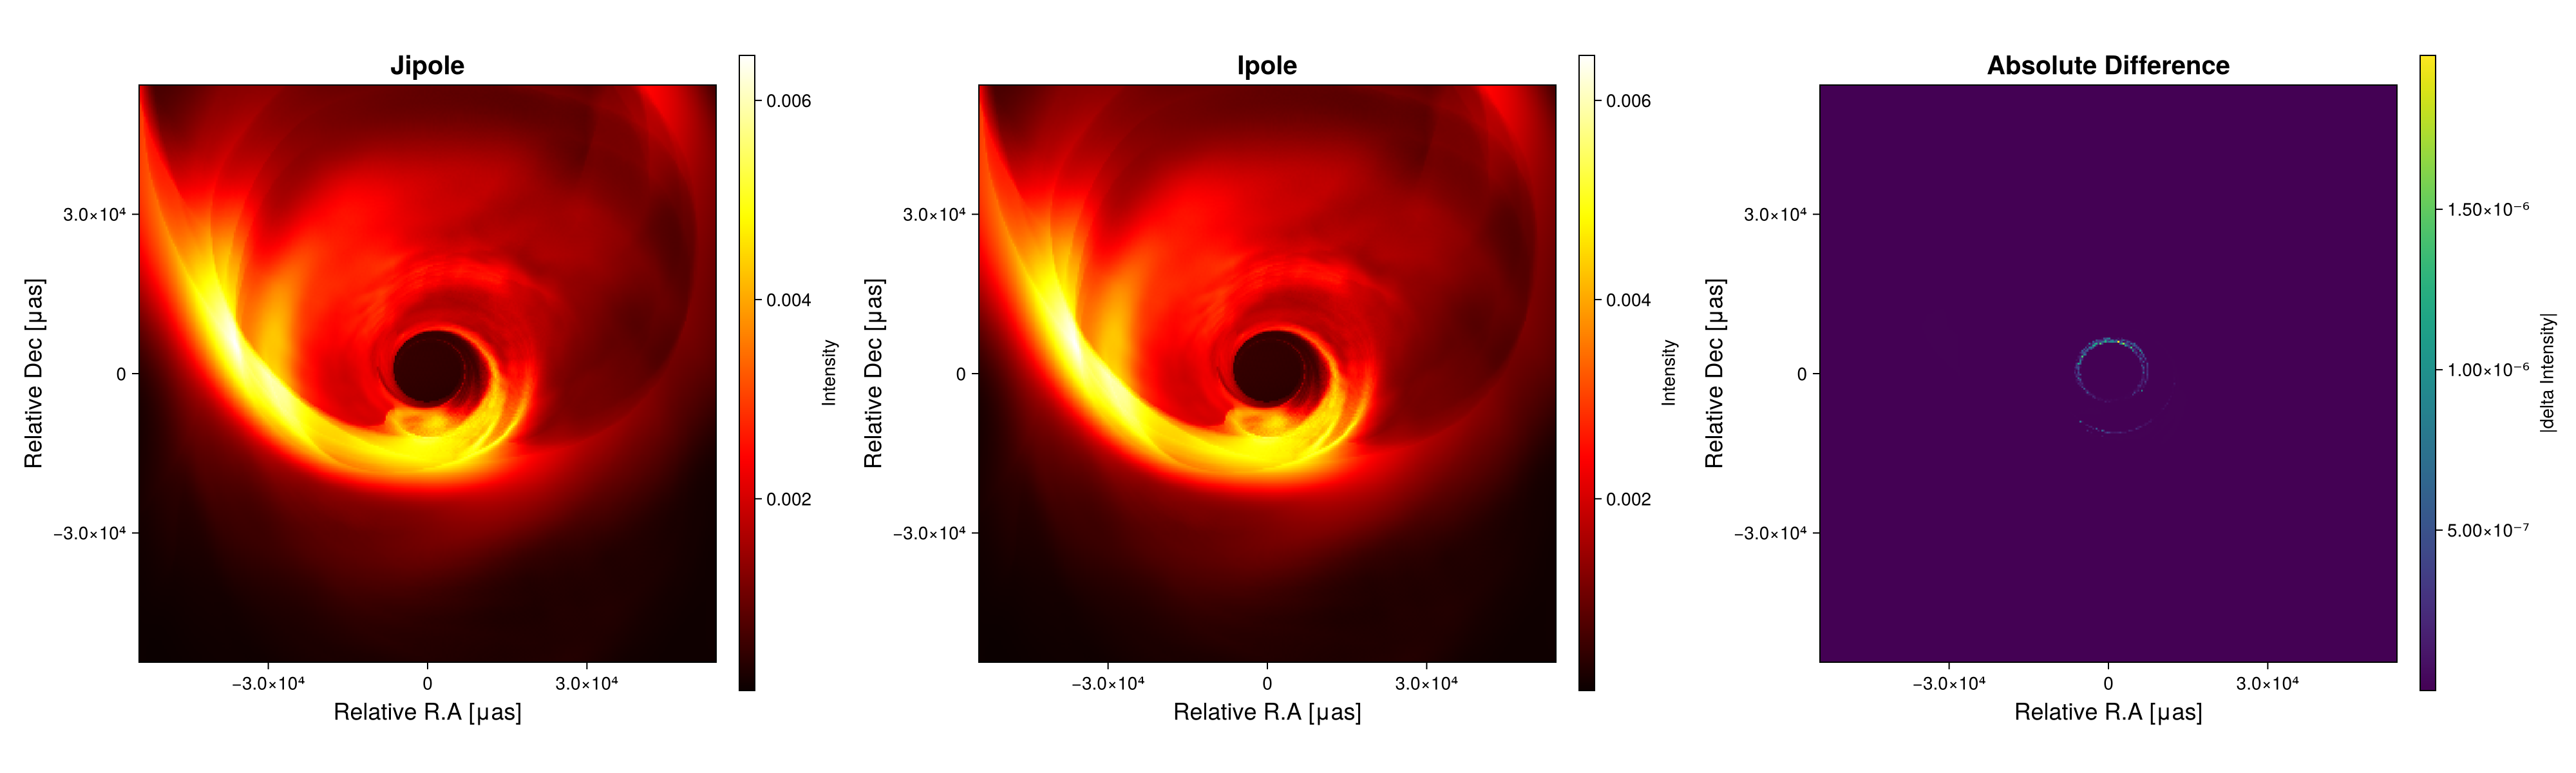

CairoMakie.Screen{IMAGE}


In [14]:
using CairoMakie
using Printf

# --- Example setup ---
img1 = Image
img2 = Image1

# Compute absolute difference
diff_img = abs.(img1 .- img2)

# Field of view & axes setup
d_kpc = 16.9
d_cm = d_kpc * 3.086e21
fov_rg = 30
half_fov_rg = fov_rg / 2
theta_rad = (half_fov_rg * L_unit) / d_cm
theta_μas = theta_rad * MUAS_PER_RAD
xlims = (-theta_μas, theta_μas)
ylims = (-theta_μas, theta_μas)

Ny, Nx = size(img1)
x = range(xlims[1], xlims[2], length=Nx)
y = range(ylims[1], ylims[2], length=Ny)

# --- Figure ---
fig = Figure(size = (2000, 600))  # Wider to accommodate colorbars

# Common color scale for first two images
crange = extrema(vcat(img1[:], img2[:]))

# Panel 1: Image 1
ax1 = Axis(fig[1, 1],
    title = "Jipole",
    xlabel = "Relative R.A [μas]",
    ylabel = "Relative Dec [μas]",
    xlabelsize = 18,
    ylabelsize = 18,
    titlesize = 20,
    limits = (xlims, ylims),
    aspect = DataAspect()
)
hm1 = heatmap!(ax1, x, y, img1; colormap = :hot, colorrange = crange)
Colorbar(fig[1, 2], hm1; label = "Intensity", labelsize = 14)

# Panel 2: Image 2
ax2 = Axis(fig[1, 3],
    title = "Ipole",
    xlabel = "Relative R.A [μas]",
    ylabel = "Relative Dec [μas]",
    xlabelsize = 18,
    ylabelsize = 18,
    titlesize = 20,
    limits = (xlims, ylims),
    aspect = DataAspect()
)
hm2 = heatmap!(ax2, x, y, img2; colormap = :hot, colorrange = crange)
Colorbar(fig[1, 4], hm2; label = "Intensity", labelsize = 14)

# Panel 3: Absolute difference
ax3 = Axis(fig[1, 5],
    title = "Absolute Difference",
    xlabel = "Relative R.A [μas]",
    ylabel = "Relative Dec [μas]",
    xlabelsize = 18,
    ylabelsize = 18,
    titlesize = 20,
    limits = (xlims, ylims),
    aspect = DataAspect()
)
hm3 = heatmap!(ax3, x, y, diff_img; colormap = :viridis)
Colorbar(fig[1, 6], hm3; label = "|delta Intensity|", labelsize = 14)

# 1. To SAVE the figure to a file:
save("my_figure.png", fig)

# 2. To DISPLAY the figure in a pop-up window:
display(fig)


In [29]:
include("../src/main.jl");

Xmvec4 = MVec4(0.0, 6.907755278982137, 0.05322792008519173, 0.0)
lconn_analytic = Tensor3D(undef)
fill!(lconn_analytic, 0.0)

spin = 0.9375
using BenchmarkTools
@btime get_connection_analytic!($Xmvec4, $lconn_analytic, $bhspin)

  3.584 μs (289 allocations: 4.53 KiB)


-8.013857346109405e-5

In [50]:
include("../src/main.jl");
lconn_FD = Tensor3D(undef)
fill!(lconn_FD, 0.0)
Xmvec4 = MVec4(0.0, 6.907755278982137, 0.05322792008519173, 0.0)
get_connection(Xmvec4, bhspin, lconn_FD)
using BenchmarkTools
@btime get_connection($Xmvec4, $bhspin, $lconn_FD)


  292.820 μs (18983 allocations: 315.45 KiB)


4×4×4 MArray{Tuple{4, 4, 4}, Float64, 3, 64} with indices SOneTo(4)×SOneTo(4)×SOneTo(4):
[:, :, 1] =
 1.99999e-9    0.001002    -2.49783e-9   -1.60277e-10
 9.97998e-10  -1.99992e-9   2.68274e-16  -7.99782e-11
 1.38473e-12  -2.8685e-12   3.72255e-19   9.95299e-11
 9.37497e-13   9.8227e-10  -3.22668e-8   -7.51297e-14

[:, :, 2] =
  0.001002     2.00189       0.0768187  -8.02987e-5
 -1.99992e-9   0.998945      0.0383326   8.01387e-5
 -2.8685e-12  -0.000695259   0.996018    5.00313e-5
  9.8227e-10   4.57504e-5   -0.0161297   0.97612

[:, :, 3] =
 -2.49783e-9    0.0768187  -55.3629      2.07213e-10
  2.68274e-16   0.0383326  -27.6261     -1.56255e-14
  3.72255e-19   0.996018    -1.82408    -2.16819e-17
 -3.22668e-8   -0.0161297   -0.0259514  17.209

[:, :, 4] =
 -1.60277e-10  -8.02987e-5   2.07213e-10  -0.170962
 -7.99782e-11   8.01387e-5  -1.56255e-14  -0.0853103
  9.95299e-11   5.00313e-5  -2.16819e-17  -0.0532603
 -7.51297e-14   0.97612     17.209        -8.01386e-5

In [49]:
include("../src/main.jl");
lconn_FD = Tensor3D(undef)
fill!(lconn_FD, 0.0)
Xmvec4 = MVec4(0.0, 6.907755278982137, 0.05322792008519173, 0.0)
get_connection(Xmvec4, bhspin, lconn_FD)
using BenchmarkTools
@btime get_connection($Xmvec4, $bhspin, $lconn_FD)
#@btime gcov_func(Xmvec4, bhspin)

  73.085 μs (3035 allocations: 56.70 KiB)


4×4×4 MArray{Tuple{4, 4, 4}, Float64, 3, 64} with indices SOneTo(4)×SOneTo(4)×SOneTo(4):
[:, :, 1] =
 2.0001e-9     0.001002     -2.49783e-9   -1.60285e-10
 9.98051e-10  -2.00002e-9    2.68288e-16  -7.99824e-11
 1.3848e-12   -2.86865e-12   3.72275e-19   9.95299e-11
 9.37547e-13   9.8227e-10   -3.22668e-8   -7.51337e-14

[:, :, 2] =
  0.001002      2.00194       0.0765128  -8.02902e-5
 -2.00002e-9    0.998972      0.0381799   8.0143e-5
 -2.86865e-12  -0.000689623   0.996017    5.00313e-5
  9.8227e-10    4.57755e-5   -0.0161298   0.97612

[:, :, 3] =
 -2.49783e-9    0.0765128  -55.3659      2.07213e-10
  2.68288e-16   0.0381799  -27.6276     -1.56264e-14
  3.72275e-19   0.996017    -1.82409    -2.16832e-17
 -3.22668e-8   -0.0161298   -0.0259528  17.209

[:, :, 4] =
 -1.60285e-10  -8.02902e-5   2.07213e-10  -0.170971
 -7.99824e-11   8.0143e-5   -1.56264e-14  -0.0853148
  9.95299e-11   5.00313e-5  -2.16832e-17  -0.0532603
 -7.51337e-14   0.97612     17.209        -8.01428e-5

In [48]:
include("../src/main.jl");
@btime gcov_func(Xmvec4, bhspin)

  6.015 μs (159 allocations: 3.44 KiB)


4×4 MMatrix{4, 4, Float64, 16} with indices SOneTo(4)×SOneTo(4):
 -0.998             2.0           0.0           -0.000160277
  2.0               1.002e6  -38410.7          -80.2989
  0.0          -38410.7           2.76815e7      0.0
 -0.000160277     -80.2989        0.0        85481.3

In [42]:
include("../src/main.jl");
@btime gcov_func_fd(Xmvec4, bhspin)

  31.468 μs (1931 allocations: 32.19 KiB)


4×4 MMatrix{4, 4, Float64, 16} with indices SOneTo(4)×SOneTo(4):
 -0.998             2.0             0.0           -0.000160277
  2.0               1.00205e6  -38410.7          -80.2989
  0.0          -38410.7             2.76815e7      0.0
 -0.000160277     -80.2989          0.0        85481.3